In [1]:
import sys
import os
import numpy as np
from IPython.display import HTML

from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories, show_training_eposides_plots_hohmann_hardcode, analyze_rl_training, analyze_multiple_runs, plot_trajectories_hohmann_scenario, plot_final_return_distribution, plot_actions_for_episode

sys.path.append(os.path.abspath("../py"))
from helpers import load_states, rank_runs_by_max_reward

# Monte Carlo REINFORCE #

## Summary of multiple runs ##

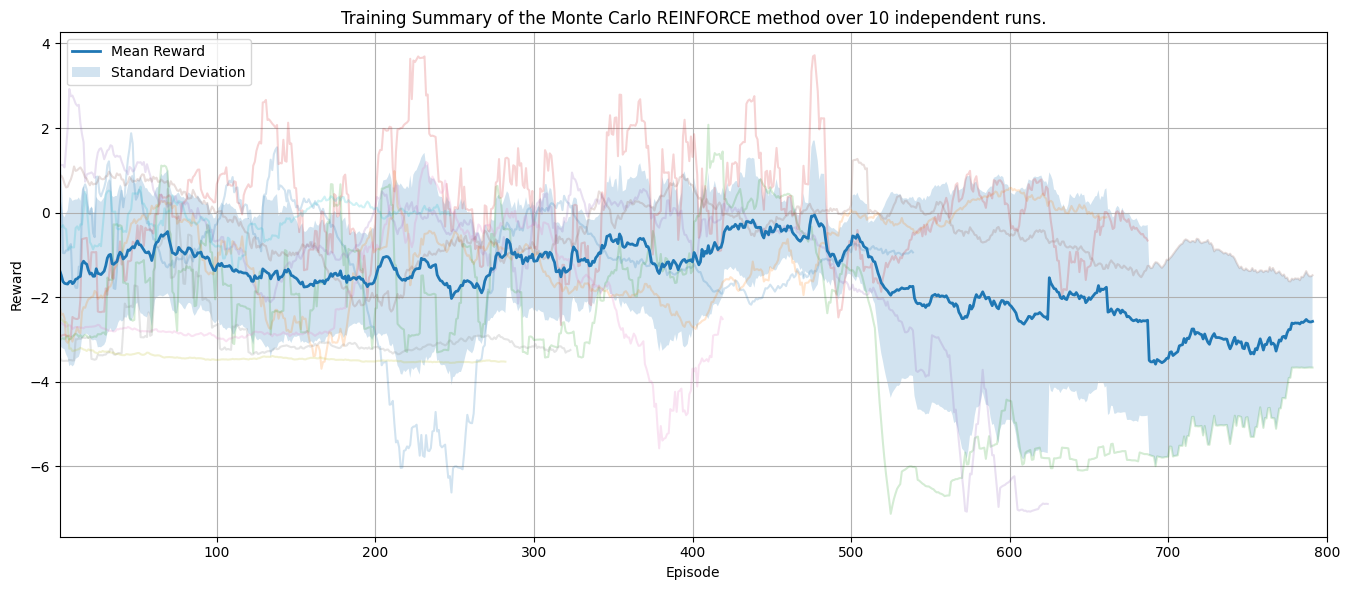

{'num_runs': 10,
 'mean_success_rate': 0.9573518256098156,
 'std_success_rate': 1.4184727846026235,
 'mean_convergence_episode': 481.75,
 'mean_convergence_time_sec': 2025.2988275625466}

In [2]:
analyze_multiple_runs(parent_folder="../../logs/training_logs/mc", max_episodes=800, ma_window=10, training_name="Training Summary of the Monte Carlo REINFORCE method over 10 independent runs.", save_path=None)#save_path="summary_mc.pdf"

## Example of a single run ##

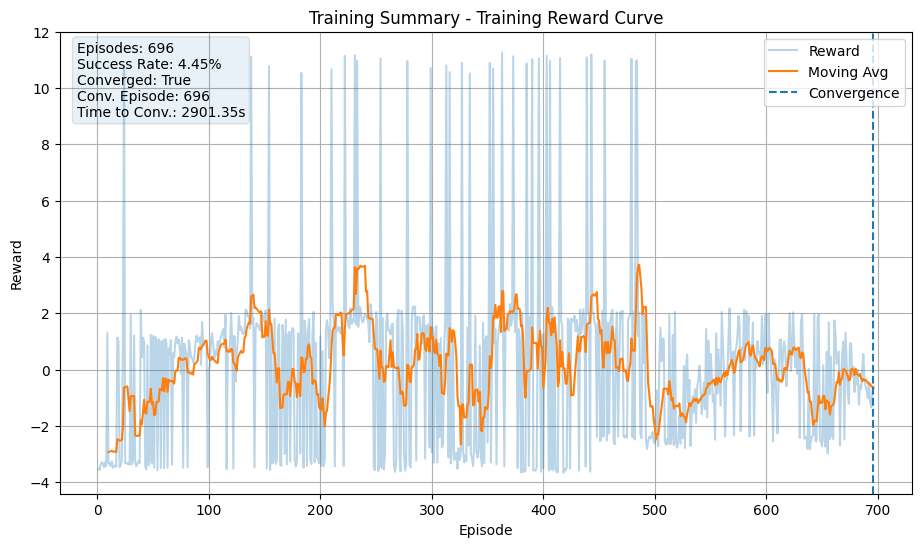

{'training_name': 'Training Summary',
 'total_episodes': 696,
 'success_rate_percent': 4.454022988505748,
 'converged': True,
 'convergence_episode': 696,
 'convergence_time_sec': 2901.350807699928}

In [3]:
analyze_rl_training("../../logs/training_logs/mc/mc_800_10500_3/metadata.json", max_episodes=800, ma_window=10)

# Advatage Actor Critic #

## Summary of multiple runs ##

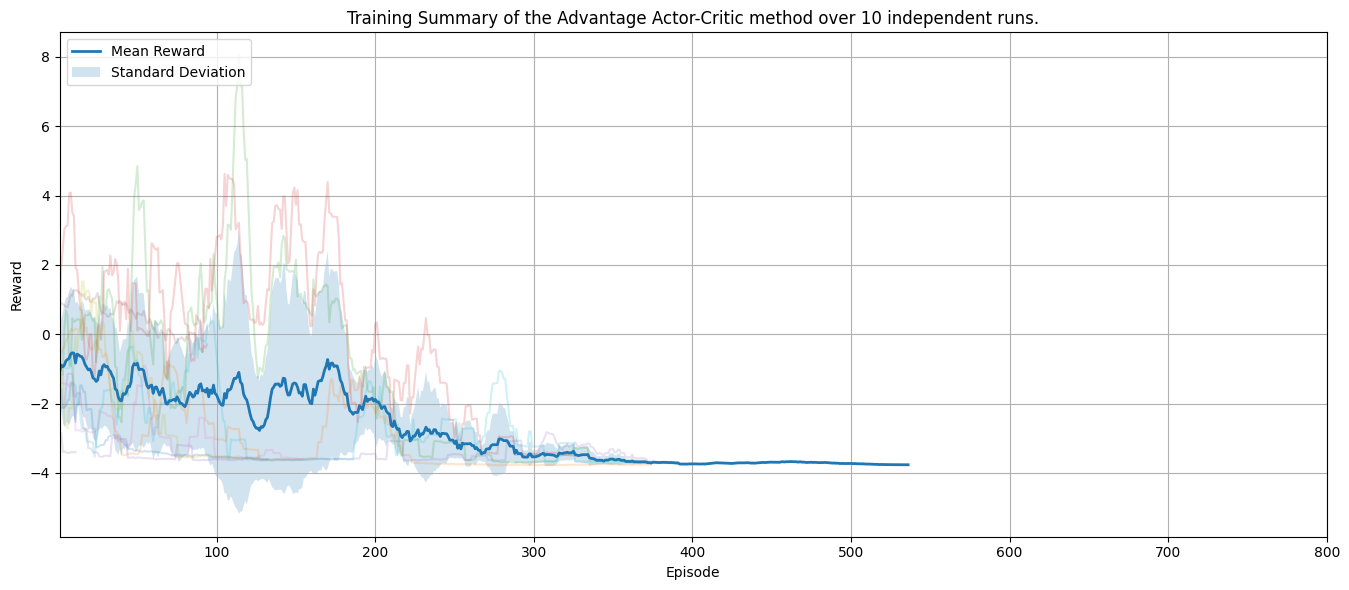

{'num_runs': 10,
 'mean_success_rate': 2.0619029609377026,
 'std_success_rate': 3.391162122476741,
 'mean_convergence_episode': 261.2,
 'mean_convergence_time_sec': 795.6625015099766}

In [4]:
analyze_multiple_runs(parent_folder="../../logs/training_logs/ac", max_episodes=800, ma_window=10, training_name="Training Summary of the Advantage Actor-Critic method over 10 independent runs.", save_path=None)#, save_path="summary_ac.pdf")

## Example of a single run ##

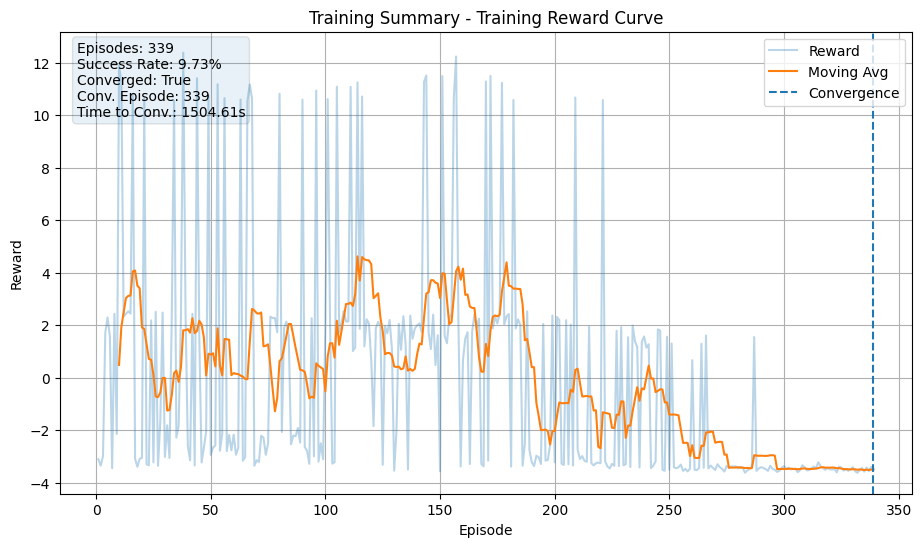

{'training_name': 'Training Summary',
 'total_episodes': 339,
 'success_rate_percent': 9.734513274336283,
 'converged': True,
 'convergence_episode': 339,
 'convergence_time_sec': 1504.6081256002071}

In [5]:
analyze_rl_training("../../logs/training_logs/ac/ac_800_10500_3/metadata.json", max_episodes=800, ma_window=10)

## Final Episode return distribution ##

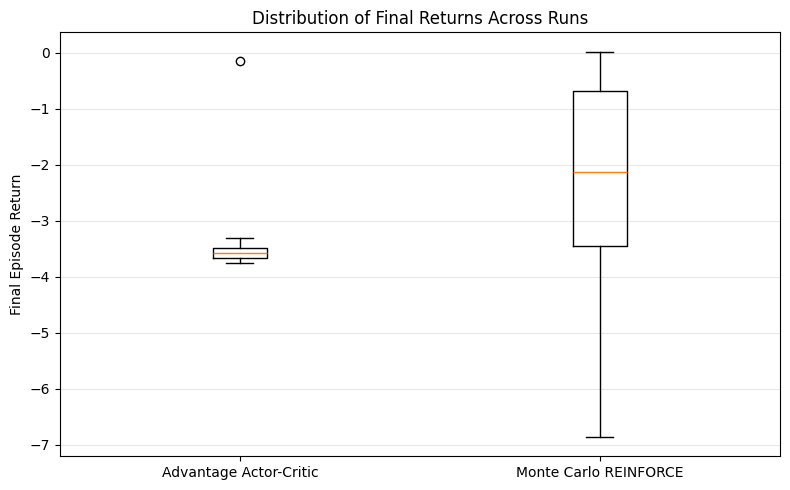

In [7]:
plot_final_return_distribution("../../logs/training_logs", save_path=None,)#, save_path="final_distr.pdf")

## Represantative Trajectory Visualisations ##

In [8]:
rank_runs_by_max_reward(root_folder="../../logs/training_logs/mc", n=5)


Run: mc_800_10500_1
--------------------------------------------------
Episode     8 | Reward: 11.879445
Episode     1 | Reward: 11.520709
Episode    34 | Reward: 11.373700
Episode    24 | Reward: 11.317802
Episode    47 | Reward: 11.162144

Run: mc_800_10500_10
--------------------------------------------------
Episode   221 | Reward: 10.637950
Episode    85 | Reward: 1.117830
Episode   609 | Reward: 1.115982
Episode   509 | Reward: 1.074780
Episode    55 | Reward: 1.064048

Run: mc_800_10500_2
--------------------------------------------------
Episode   133 | Reward: 11.288784
Episode    69 | Reward: 11.257128
Episode   181 | Reward: 11.183154
Episode    85 | Reward: 11.103310
Episode   410 | Reward: 11.042364

Run: mc_800_10500_3
--------------------------------------------------
Episode   363 | Reward: 11.255085
Episode   443 | Reward: 11.193303
Episode   231 | Reward: 11.164965
Episode   403 | Reward: 11.142468
Episode   222 | Reward: 11.140621

Run: mc_800_10500_4
--------------

In [9]:
bodies = [np.array([5.972e24, 1.0e5,]),
        np.array([[0.0, 0.0],[6.371e6+2e6, 0.0],]),
        np.array([[0.0, 0.0],[0.0, 6.9e3],]),
        np.array(["Earth","Spacecraft Trajectory"]),
        np.array(["lightblue","purple",]),]
centre_body="Earth"
scale=1.0/1e3
xlim=(-1.5e4, 1.5e4)
ylim=(-1.5e4, 1.5e4)
xlabel="x [km]"
ylabel="y [km]"

In [10]:
states = load_states("../../logs/training_logs/mc/mc_800_10500_2/episodes/episode410.json")

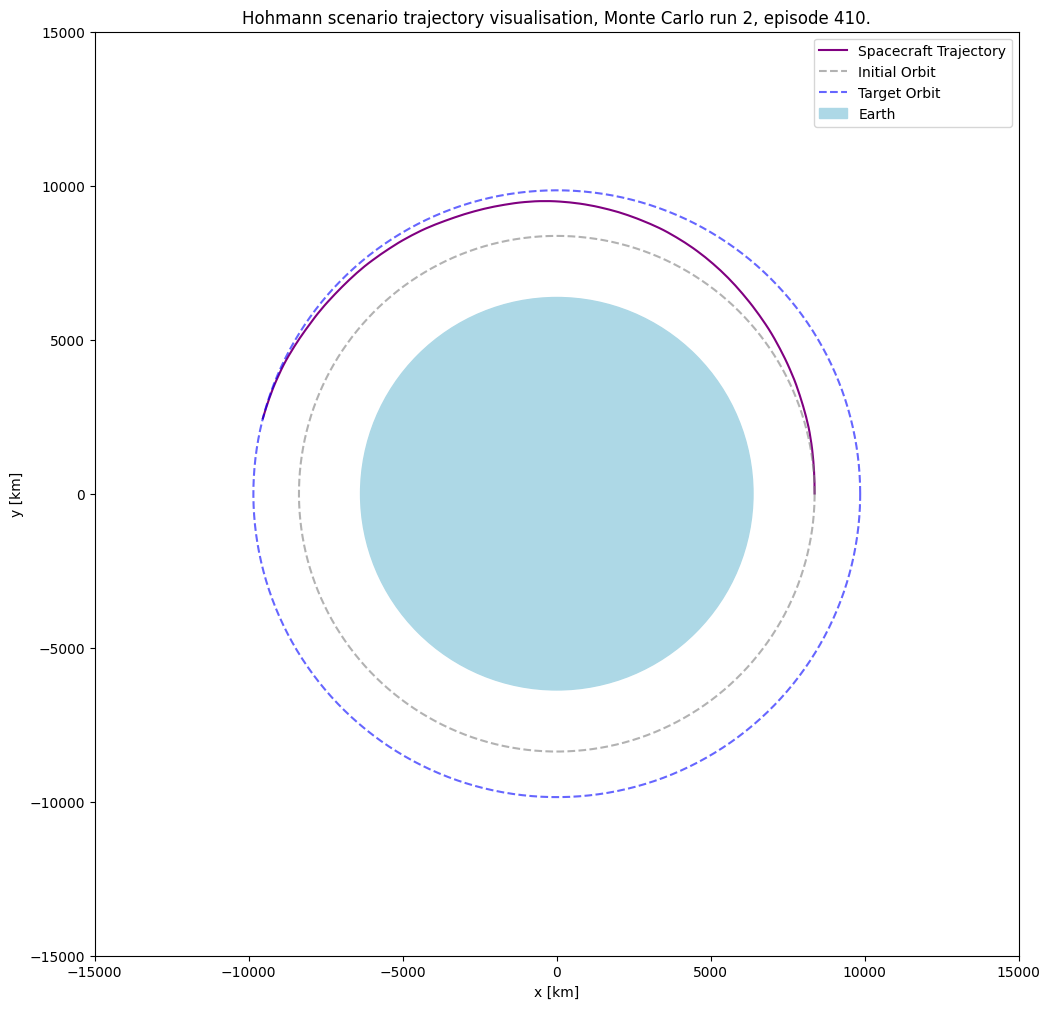

In [11]:
plot_trajectories_hohmann_scenario(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel,
                                   title="Hohmann scenario trajectory visualisation, Monte Carlo run 2, episode 410.", save_path=None,)#save_path="Best_mc_episode.pdf",

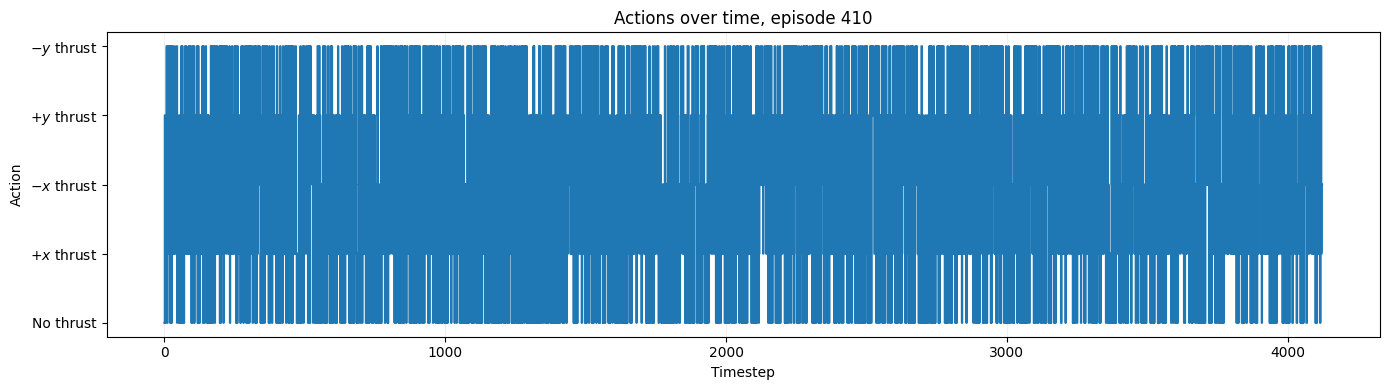

In [12]:
plot_actions_for_episode(run_folder="../../logs/training_logs/mc/mc_800_10500_2", episode_number=410, zero_indexed=False, save_path=None,)#, save_path="mc_actions.pdf") #

In [13]:
rank_runs_by_max_reward(root_folder="../../logs/training_logs/ac", n=5)


Run: ac_800_10500_1
--------------------------------------------------
Episode     9 | Reward: 2.491051
Episode    10 | Reward: 2.430560
Episode     2 | Reward: 2.415515
Episode    21 | Reward: 2.406575
Episode    23 | Reward: 2.392581

Run: ac_800_10500_10
--------------------------------------------------
Episode    74 | Reward: 2.057896
Episode    70 | Reward: 1.842870
Episode    94 | Reward: 1.608330
Episode    25 | Reward: 1.549857
Episode   180 | Reward: 1.523814

Run: ac_800_10500_2
--------------------------------------------------
Episode    66 | Reward: 11.701145
Episode    57 | Reward: 11.601535
Episode    56 | Reward: 11.208093
Episode   123 | Reward: 11.099661
Episode    37 | Reward: 10.973120

Run: ac_800_10500_3
--------------------------------------------------
Episode    38 | Reward: 12.372824
Episode   157 | Reward: 12.227573
Episode    10 | Reward: 11.880265
Episode   144 | Reward: 11.507764
Episode   172 | Reward: 11.492143

Run: ac_800_10500_4
--------------------

In [14]:
states = load_states("../../logs/training_logs/ac/ac_800_10500_3/episodes/episode10.json")

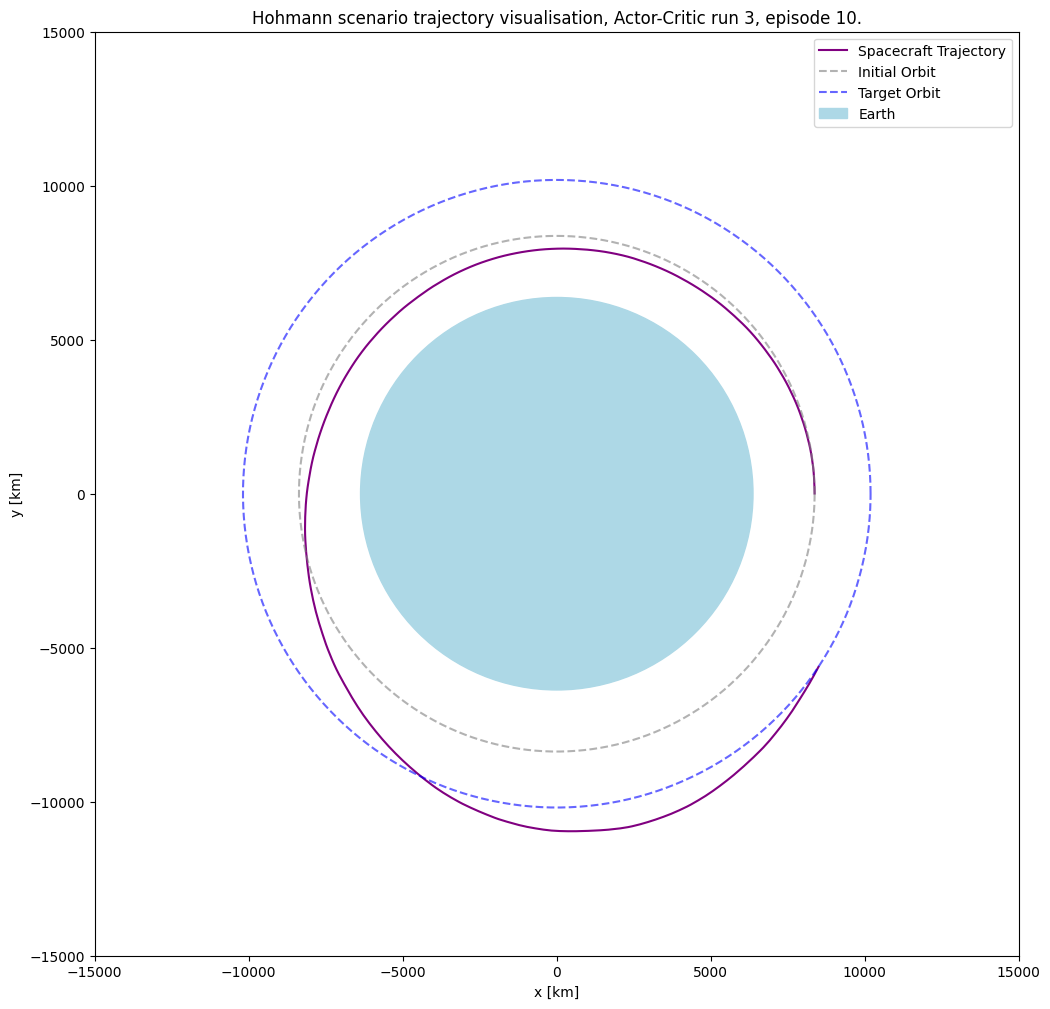

In [15]:
plot_trajectories_hohmann_scenario(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel,
                                   title="Hohmann scenario trajectory visualisation, Actor-Critic run 3, episode 10.", save_path=None)#,, save_path="Best_ac_episode.pdf",)

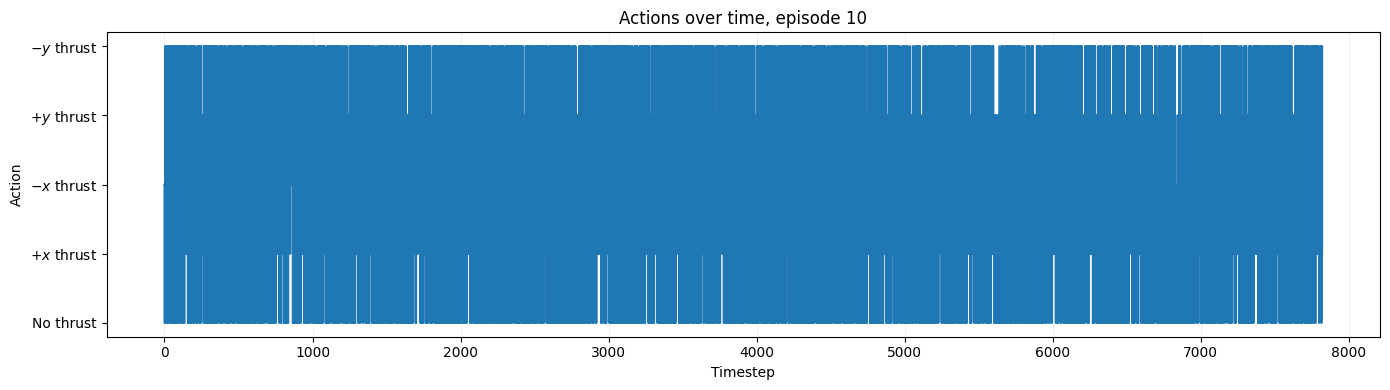

In [16]:
plot_actions_for_episode(run_folder="../../logs/training_logs/ac/ac_800_10500_3", episode_number=10, zero_indexed=False, save_path=None)#,, save_path="ac_actions.pdf") 